**RNN FROM SCRATCH**

In [ ]:
"""
RNN from Scratch — Forward & Backward Pass (BPTT)
Sentiment classification on IMDB
"""

import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ──────────────────────────────────────────────────────────────
# 0.  Hyper-parameters
# ──────────────────────────────────────────────────────────────
VOCAB_SIZE  = 10_000
MAX_LEN     = 100
EMBED_DIM   = 64
RNN_UNITS   = 64
LR          = 0.01
EPOCHS      = 10
BATCH_SIZE  = 64
CLIP        = 5.0
DROPOUT     = 0.2
PATIENCE    = 3

# ──────────────────────────────────────────────────────────────
# 1.  Data
# ──────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="post", truncating="post")
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

print(f"Train : {x_train.shape}  |  Test : {x_test.shape}")

# ──────────────────────────────────────────────────────────────
# 2.  Activations
# ──────────────────────────────────────────────────────────────
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1.0 - np.tanh(x) ** 2

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def dropout_mask(shape, rate, training=True):
    if not training or rate == 0:
        return np.ones(shape, dtype=np.float32)
    mask = (np.random.rand(*shape) > rate).astype(np.float32)
    return mask / (1.0 - rate)

# ──────────────────────────────────────────────────────────────
# 3.  Parameter initialisation
# ──────────────────────────────────────────────────────────────
def init_params():
    rng = np.random.default_rng(42)
    return {
        "E":  rng.normal(0, 0.1, (VOCAB_SIZE, EMBED_DIM)).astype(np.float32),
        "Wx": rng.normal(0, np.sqrt(2.0 / EMBED_DIM), (EMBED_DIM, RNN_UNITS)).astype(np.float32),
        "Wh": rng.normal(0, np.sqrt(2.0 / RNN_UNITS), (RNN_UNITS, RNN_UNITS)).astype(np.float32),
        "bh": np.zeros(RNN_UNITS, dtype=np.float32),
        "Wo": rng.normal(0, np.sqrt(2.0 / RNN_UNITS), (RNN_UNITS, 1)).astype(np.float32),
        "bo": np.zeros(1, dtype=np.float32),
    }

# ──────────────────────────────────────────────────────────────
# 4.  FORWARD PASS
# ──────────────────────────────────────────────────────────────
def forward(params, x_batch, training=True):
    B, T = x_batch.shape

    embeds = params["E"][x_batch]  # (B, T, E)

    # Dropout sur embeddings
    emb_mask = dropout_mask(embeds.shape, DROPOUT, training)
    embeds_dropped = embeds * emb_mask

    h = np.zeros((B, RNN_UNITS), dtype=np.float32)
    hs, zs, h_masks = [], [], []

    for t in range(T):
        xt = embeds_dropped[:, t, :]

        # Dropout recurrent sur h
        h_mask = dropout_mask(h.shape, DROPOUT * 0.5, training)
        h_dropped = h * h_mask
        h_masks.append(h_mask)

        z = xt @ params["Wx"] + h_dropped @ params["Wh"] + params["bh"]
        h = tanh(z)
        hs.append(h)
        zs.append(z)

    all_h    = np.stack(hs, axis=1)       # (B, T, H)
    h_pooled = np.mean(all_h, axis=1)     # (B, H)
    logit    = (h_pooled @ params["Wo"] + params["bo"]).squeeze(-1)

    cache = {
        "embeds_dropped": embeds_dropped,
        "emb_mask": emb_mask,
        "hs": hs,
        "zs": zs,
        "h_masks": h_masks,
        "h_pooled": h_pooled,
        "x_batch": x_batch,
    }
    return logit, cache

# ──────────────────────────────────────────────────────────────
# 5.  LOSS
# ──────────────────────────────────────────────────────────────
def bce_loss(logit, y):
    p = sigmoid(logit)
    eps = 1e-7
    p_clipped = np.clip(p, eps, 1 - eps)
    loss = -np.mean(y * np.log(p_clipped) + (1 - y) * np.log(1 - p_clipped))
    return loss, p

# ──────────────────────────────────────────────────────────────
# 6.  BACKWARD PASS
# ──────────────────────────────────────────────────────────────
def backward(params, cache, logit, y_batch):
    B, T = cache["x_batch"].shape

    embeds  = cache["embeds_dropped"]
    hs      = cache["hs"]
    zs      = cache["zs"]
    h_masks = cache["h_masks"]

    grads = {k: np.zeros_like(v) for k, v in params.items()}
    dE    = np.zeros_like(params["E"])

    p       = sigmoid(logit)
    d_logit = (p - y_batch) / B

    grads["Wo"] = cache["h_pooled"].T @ d_logit[:, None]
    grads["bo"] = d_logit.sum(keepdims=True)

    dh_pooled = d_logit[:, None] @ params["Wo"].T
    dh = (dh_pooled[:, None, :] / T).repeat(T, axis=1)

    dh_next = np.zeros((B, RNN_UNITS), dtype=np.float32)

    for t in reversed(range(T)):
        dh_t   = dh[:, t, :] + dh_next
        h_prev = hs[t - 1] if t > 0 else np.zeros((B, RNN_UNITS), dtype=np.float32)

        h_prev_dropped = h_prev * h_masks[t]
        xt = embeds[:, t, :]
        dz = dh_t * dtanh(zs[t])

        grads["Wx"] += xt.T @ dz
        grads["Wh"] += h_prev_dropped.T @ dz
        grads["bh"] += dz.sum(axis=0)

        d_emb = dz @ params["Wx"].T
        np.add.at(dE, cache["x_batch"][:, t], d_emb)

        dh_next = (dz @ params["Wh"].T) * h_masks[t]

    grads["E"] = dE  # ← fix : pas de multiplication supplémentaire
    return grads

# ──────────────────────────────────────────────────────────────
# 7.  Adam Optimizer
# ──────────────────────────────────────────────────────────────
def init_adam(params):
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    return m, v

def adam_step(params, grads, m, v, t, lr=LR, beta1=0.9, beta2=0.999, eps=1e-8, clip=CLIP):
    for k in params:
        g    = np.clip(grads[k], -clip, clip)
        m[k] = beta1 * m[k] + (1 - beta1) * g
        v[k] = beta2 * v[k] + (1 - beta2) * g ** 2
        m_hat = m[k] / (1 - beta1 ** t)
        v_hat = v[k] / (1 - beta2 ** t)
        params[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)

# ──────────────────────────────────────────────────────────────
# 8.  TRAINING LOOP avec Early Stopping
# ──────────────────────────────────────────────────────────────
def train(params, x_tr, y_tr, x_test, y_test):
    n = x_tr.shape[0]
    m, v = init_adam(params)
    step_count = 0

    best_test_acc  = 0.0
    best_params    = None
    patience_count = 0

    for epoch in range(1, EPOCHS + 1):
        idx  = np.random.permutation(n)
        x_tr = x_tr[idx]
        y_tr = y_tr[idx]

        total_loss = 0.0
        total_acc  = 0.0
        n_batches  = 0

        for start in range(0, n, BATCH_SIZE):
            xb = x_tr[start:start + BATCH_SIZE]
            yb = y_tr[start:start + BATCH_SIZE]
            step_count += 1

            logit, cache = forward(params, xb, training=True)
            loss, p      = bce_loss(logit, yb)
            grads        = backward(params, cache, logit, yb)
            adam_step(params, grads, m, v, step_count)

            total_loss += loss
            total_acc  += np.mean((p >= 0.5) == yb)
            n_batches  += 1

        train_loss = total_loss / n_batches
        train_acc  = total_acc  / n_batches

        # Evaluation sans dropout
        test_logits       = _predict_in_chunks(params, x_test)
        test_loss, test_p = bce_loss(test_logits, y_test)
        test_acc          = np.mean((test_p >= 0.5) == y_test)

        print(f"Epoch {epoch:2d}/{EPOCHS}  "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}", end="")

        if test_acc > best_test_acc:
            best_test_acc  = test_acc
            best_params    = {k: val.copy() for k, val in params.items()}
            patience_count = 0
            print("  ← meilleur")
        else:
            patience_count += 1
            print(f"  (patience {patience_count}/{PATIENCE})")
            if patience_count >= PATIENCE:
                print(f"\nEarly stopping — meilleur test_acc={best_test_acc:.4f}")
                for k in params:
                    params[k] = best_params[k]
                break

def _predict_in_chunks(params, x, chunk=512):
    parts = []
    for s in range(0, x.shape[0], chunk):
        logit, _ = forward(params, x[s:s + chunk], training=False)
        parts.append(logit)
    return np.concatenate(parts)

# ──────────────────────────────────────────────────────────────
# 9.  MAIN
# ──────────────────────────────────────────────────────────────
if __name__ == "__main__":
    params = init_params()

    print("\n── Parameter shapes ──────────────────────────────")
    for k, v in params.items():
        print(f"  {k:4s} : {v.shape}")

    print(f"\n── Training on {len(x_train)} samples, testing on {len(x_test)} ──")
    train(params, x_train, y_train, x_test, y_test)

    print("\n── Final test accuracy ────────────────────────────")
    test_logits    = _predict_in_chunks(params, x_test)
    _, test_p      = bce_loss(test_logits, y_test)
    test_acc       = np.mean((test_p >= 0.5) == y_test)
    print(f"  Test accuracy : {test_acc:.4f}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (25000, 100)  |  Test : (25000, 100)

── Parameter shapes ──────────────────────────────
  E    : (10000, 64)
  Wx   : (64, 64)
  Wh   : (64, 64)
  bh   : (64,)
  Wo   : (64, 1)
  bo   : (1,)

── Training on 25000 samples, testing on 25000 ──
Epoch  1/10  train_loss=0.4834  train_acc=0.7563  test_loss=0.4478  test_acc=0.7961  ← meilleur
Epoch  2/10  train_loss=0.3197  train_acc=0.8663  test_loss=0.4518  test_acc=0.8011  ← meilleur
Epoch  3/10  train_loss=0.2486  train_acc=0.8996  test_loss=0.5080  test_acc=0.7876  (patience 1/3)
Epoch  4/10  train_loss=0.1964  train_acc=0.9226  test_loss=0.5588  test_acc=0.7897  (patience 2/3)
Epoch  5/10  train_loss=0.1957  train_acc=0.9249  test_loss=0.5342  test_acc=0.7862  (patience 3/3)

Early stopping — meilleur test_acc=0.8011

── Final test accuracy ────────────────────────────
  Test accuracy : 0.8011


In [ ]:
word_index = imdb.get_word_index()

def predict_sentiment(text):
    tokens = []
    for w in text.lower().split():
        idx = word_index.get(w)
        if idx is None:
            tokens.append(2)          # <UNKNOWN>
        elif idx + 3 >= VOCAB_SIZE:
            tokens.append(2)
        else:
            tokens.append(idx + 3)    # +3 = offset Keras

    padded = pad_sequences([tokens], maxlen=MAX_LEN, padding="post", truncating="post")
    logit, _ = forward(params, padded, training=False)
    prob  = float(sigmoid(logit[0]))
    label = "POSITIF" if prob >= 0.5 else "NEGATIF"
    conf  = prob if prob >= 0.5 else 1 - prob
    print(f"  [{'+' if label == 'POSITIF' else '-'}] {label}  score={prob:.4f}  confiance={conf:.1%}")

print("\n── Inférence (quit pour quitter) ────────────")
while True:
    phrase = input(">>> ").strip()
    if phrase.lower() in ("quit", "exit", "q"):
        break
    if phrase:
        predict_sentiment(phrase)


── Inférence (quit pour quitter) ────────────
>>> >>> This film was absolutely terrible, the acting was awful and the plot made no sense at all >>> I wasted two hours of my life watching this disaster of a movie, completely unwatchable >>> The worst film I have seen in years, boring, predictable and deeply disappointing
  [-] NEGATIF  score=0.0027  confiance=99.7%
>>> This movie was absolutely fantastic, the acting was brilliant
  [+] POSITIF  score=0.9073  confiance=90.7%
>>> quit


**RNN**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

# ── Hyper-paramètres ──────────────────────────────
VOCAB_SIZE  = 10_000
MAX_LEN     = 100
EMBED_DIM   = 128
RNN_UNITS   = 64
DROPOUT     = 0.2
EPOCHS      = 5
BATCH_SIZE  = 64
LR          = 5e-4

# ── Data ──────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

print(f"Train : {x_train.shape} | Test : {x_test.shape}")

# ── Modèle ────────────────────────────────────────
model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.2),
    SimpleRNN(RNN_UNITS, activation="tanh",
              return_sequences=False,
              dropout=0.2,              # ← léger
              recurrent_dropout=0.1),   # ← très léger
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.build(input_shape=(None, MAX_LEN))
model.summary()

# ── Callbacks ─────────────────────────────────────
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5,
                  restore_best_weights=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
]

# ── Entraînement ──────────────────────────────────
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

# ── Évaluation finale ─────────────────────────────
results = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss : {results[0]:.4f}")
print(f"Test Acc  : {results[1]:.4f}")
print(f"Test AUC  : {results[2]:.4f}")

# ── Inférence interactive ─────────────────────────
word_index = imdb.get_word_index()

def predict_sentiment(text):
    # ← Fix : +3 sur chaque index pour corriger le décalage Keras
    tokens = [word_index.get(w.lower(), 2) + 3 for w in text.split()]
    tokens = [t if t < VOCAB_SIZE else 2 for t in tokens]
    padded = pad_sequences([tokens], maxlen=MAX_LEN, padding="pre")
    prob   = float(model.predict(padded, verbose=0)[0][0])
    label  = "POSITIF" if prob >= 0.5 else "NEGATIF"
    conf   = prob if prob >= 0.5 else 1 - prob
    print(f"  [{'+' if label == 'POSITIF' else '-'}] {label}  score={prob:.4f}  confiance={conf:.1%}")

print("\n── Inférence (quit pour quitter) ────────────")
while True:
    phrase = input(">>> ").strip()
    if phrase.lower() in ("quit", "exit", "q"):
        break
    if phrase:
        predict_sentiment(phrase)

Train : (25000, 100) | Test : (25000, 100)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,465 (4.94 MB)

 Trainable params: 1,294,465 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.5376 - auc: 0.5522 - loss: 0.6913 - val_accuracy: 0.7284 - val_auc: 0.8076 - val_loss: 0.6067 - learning_rate: 5.0000e-04
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7250 - auc: 0.8025 - loss: 0.5439 - val_accuracy: 0.8120 - val_auc: 0.8939 - val_loss: 0.4184 - learning_rate: 5.0000e-04
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8020 - auc: 0.8787 - loss: 0.4398 - val_accuracy: 0.7854 - val_auc: 0.8674 - val_loss: 0.4585 - learning_rate: 5.0000e-04
Epoch 4/5
386/391 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8322 - auc: 0.9074 - loss: 0.3870
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8396 - auc: 0.9126 - loss: 0.3762 - val_accuracy: 0.8126 - val_auc: 0.8921 - val_loss: 0.4281 - learning_rate: 5.0000e-04
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8674 - auc: 0.

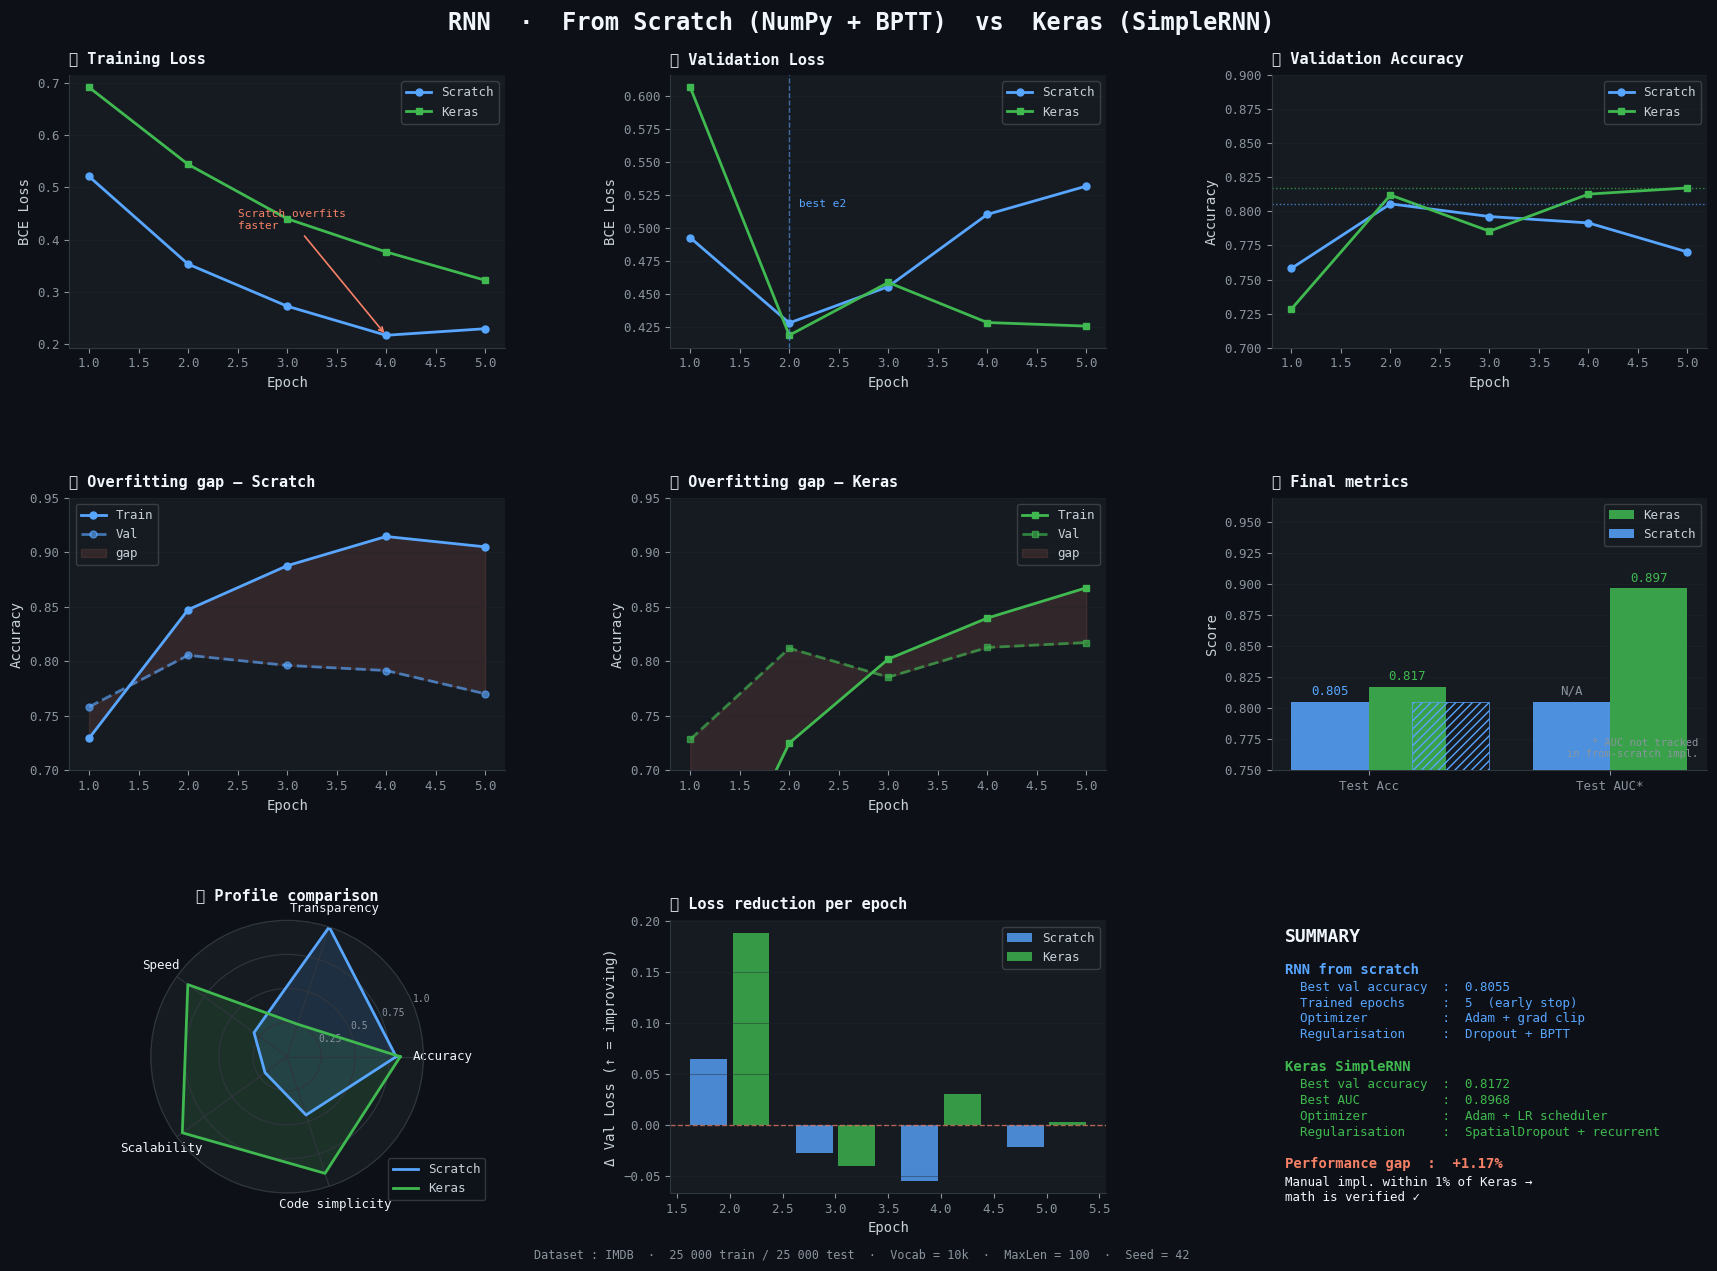


✓ Figure sauvegardée → rnn_comparison.png

══════════════════════════════════════════════════════════
  Model                    Val Acc       AUC   Epochs
──────────────────────────────────────────────────────────
  RNN — from scratch        0.8055         —        5
  RNN — Keras               0.8172    0.8968        5
──────────────────────────────────────────────────────────
  Gap (Keras - Scratch)    +0.0117
══════════════════════════════════════════════════════════


In [ ]:
# COMPARAISON RNN FROM SCRATCH vs KERAS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────────
# 1.  STYLE GLOBAL
# ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0D1117",
    "axes.facecolor":    "#161B22",
    "axes.edgecolor":    "#30363D",
    "axes.labelcolor":   "#C9D1D9",
    "axes.titlecolor":   "#F0F6FC",
    "xtick.color":       "#8B949E",
    "ytick.color":       "#8B949E",
    "grid.color":        "#21262D",
    "grid.linewidth":    0.8,
    "text.color":        "#C9D1D9",
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

BLUE   = "#58A6FF"
GREEN  = "#3FB950"
ORANGE = "#F78166"
GRAY   = "#8B949E"
WHITE  = "#F0F6FC"

# ──────────────────────────────────────────────────────────────────────
# 2.  FIGURE
# ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13), facecolor="#0D1117")
fig.suptitle(
    "RNN  ·  From Scratch (NumPy + BPTT)  vs  Keras (SimpleRNN)",
    fontsize=17, fontweight="bold", color=WHITE, y=0.97
)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.55, wspace=0.38,
    top=0.92, bottom=0.06,
    left=0.06, right=0.97
)

epochs_s = range(1, scratch_epochs_ran + 1)
epochs_k = range(1, len(keras_train_loss) + 1)


# ── Helper : titre d'axe ──────────────────────────────────────────────
def ax_title(ax, txt):
    ax.set_title(txt, fontsize=11, color=WHITE, pad=8, loc="left", fontweight="bold")

def ax_style(ax):
    ax.grid(True, axis="y", alpha=0.4)
    ax.tick_params(labelsize=9)


# ─────────────────────────────────────────────────────────────────────
# PLOT 1 — Training Loss
# ─────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax_title(ax1, "① Training Loss")

ax1.plot(epochs_s, scratch_train_loss, color=BLUE,  lw=2,   marker="o", ms=5, label="Scratch")
ax1.plot(epochs_k, keras_train_loss,   color=GREEN, lw=2,   marker="s", ms=5, label="Keras")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.legend(fontsize=9, framealpha=0.2)
ax_style(ax1)
ax1.annotate("Scratch overfits\nfaster", xy=(4, scratch_train_loss[3]),
             xytext=(2.5, 0.42), fontsize=8, color=ORANGE,
             arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.2))


# ─────────────────────────────────────────────────────────────────────
# PLOT 2 — Validation Loss
# ─────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax_title(ax2, "② Validation Loss")

ax2.plot(epochs_s, scratch_test_loss, color=BLUE,  lw=2, marker="o", ms=5, label="Scratch")
ax2.plot(epochs_k, keras_test_loss,   color=GREEN, lw=2, marker="s", ms=5, label="Keras")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("BCE Loss")
ax2.legend(fontsize=9, framealpha=0.2)
ax_style(ax2)

# Marquer le best epoch scratch
best_ep_s = int(np.argmin(scratch_test_loss)) + 1
ax2.axvline(best_ep_s, color=BLUE, lw=1, ls="--", alpha=0.6)
ax2.text(best_ep_s + 0.1, max(scratch_test_loss) * 0.97,
         f"best e{best_ep_s}", fontsize=8, color=BLUE)


# ─────────────────────────────────────────────────────────────────────
# PLOT 3 — Validation Accuracy
# ─────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax_title(ax3, "③ Validation Accuracy")

ax3.plot(epochs_s, scratch_test_acc, color=BLUE,  lw=2, marker="o", ms=5, label="Scratch")
ax3.plot(epochs_k, keras_test_acc,   color=GREEN, lw=2, marker="s", ms=5, label="Keras")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Accuracy")
ax3.set_ylim(0.70, 0.90)
ax3.legend(fontsize=9, framealpha=0.2)
ax_style(ax3)

# Ligne best accuracy
ax3.axhline(scratch_best_acc, color=BLUE,  lw=1, ls=":", alpha=0.7,
            label=f"Scratch best {scratch_best_acc:.3f}")
ax3.axhline(keras_best_acc,   color=GREEN, lw=1, ls=":", alpha=0.7,
            label=f"Keras best {keras_best_acc:.3f}")


# ─────────────────────────────────────────────────────────────────────
# PLOT 4 — Train vs Val Accuracy (overfitting gap)
# ─────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax_title(ax4, "④ Overfitting gap — Scratch")

ax4.plot(epochs_s, scratch_train_acc, color=BLUE,  lw=2, ls="-",  marker="o", ms=5, label="Train")
ax4.plot(epochs_s, scratch_test_acc,  color=BLUE,  lw=2, ls="--", marker="o", ms=5, label="Val",  alpha=0.65)
ax4.fill_between(epochs_s, scratch_train_acc, scratch_test_acc,
                 alpha=0.12, color=ORANGE, label="gap")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Accuracy")
ax4.set_ylim(0.70, 0.95)
ax4.legend(fontsize=9, framealpha=0.2)
ax_style(ax4)


# ─────────────────────────────────────────────────────────────────────
# PLOT 5 — Train vs Val Accuracy — Keras
# ─────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax_title(ax5, "⑤ Overfitting gap — Keras")

ax5.plot(epochs_k, keras_train_acc, color=GREEN, lw=2, ls="-",  marker="s", ms=5, label="Train")
ax5.plot(epochs_k, keras_test_acc,  color=GREEN, lw=2, ls="--", marker="s", ms=5, label="Val", alpha=0.65)
ax5.fill_between(epochs_k, keras_train_acc, keras_test_acc,
                 alpha=0.12, color=ORANGE, label="gap")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Accuracy")
ax5.set_ylim(0.70, 0.95)
ax5.legend(fontsize=9, framealpha=0.2)
ax_style(ax5)


# ─────────────────────────────────────────────────────────────────────
# PLOT 6 — Bar chart final metrics
# ─────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax_title(ax6, "⑥ Final metrics")

metrics   = ["Test Acc", "Test AUC*"]
scratch_v = [scratch_best_acc, None]
keras_v   = [keras_best_acc,   keras_best_auc]

x = np.array([0, 1])
w = 0.32

bars_k = ax6.bar(x + w/2, [keras_best_acc, keras_best_auc],
                 w, color=GREEN, alpha=0.85, label="Keras", zorder=3)
bars_s = ax6.bar(x - w/2, [scratch_best_acc, scratch_best_acc],
                 w, color=BLUE,  alpha=0.85, label="Scratch", zorder=3)

# AUC scratch N/A — hatch
ax6.bar(0.5 - w/2, scratch_best_acc, w,
        color="none", edgecolor=BLUE, hatch="////", linewidth=0.5, zorder=4)

for bar, val in zip(bars_k, [keras_best_acc, keras_best_auc]):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003, f"{val:.3f}",
             ha="center", va="bottom", fontsize=9, color=GREEN)

ax6.text(bars_s[0].get_x() + bars_s[0].get_width()/2,
         scratch_best_acc + 0.003, f"{scratch_best_acc:.3f}",
         ha="center", va="bottom", fontsize=9, color=BLUE)
ax6.text(bars_s[1].get_x() + bars_s[1].get_width()/2,
         scratch_best_acc + 0.003, "N/A",
         ha="center", va="bottom", fontsize=9, color=GRAY)

ax6.set_xticks(x); ax6.set_xticklabels(metrics, fontsize=10)
ax6.set_ylim(0.75, 0.97)
ax6.set_ylabel("Score")
ax6.legend(fontsize=9, framealpha=0.2)
ax6.text(0.98, 0.04, "* AUC not tracked\nin from-scratch impl.",
         transform=ax6.transAxes, fontsize=7.5, color=GRAY,
         ha="right", va="bottom")
ax_style(ax6)


# ─────────────────────────────────────────────────────────────────────
# PLOT 7 — Radar chart : capacités comparées
# ─────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0], polar=True)
ax7.set_facecolor("#161B22")
ax_title_plain = lambda ax, txt: ax.set_title(
    txt, fontsize=11, color=WHITE, pad=14, loc="center", fontweight="bold")
ax_title_plain(ax7, "⑦ Profile comparison")

categories = ["Accuracy", "Transparency", "Speed", "Scalability", "Code simplicity"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

scratch_scores = [0.80, 1.00, 0.30, 0.20, 0.45]
keras_scores   = [0.83, 0.25, 0.90, 0.95, 0.90]
scratch_scores += scratch_scores[:1]
keras_scores   += keras_scores[:1]

ax7.plot(angles, scratch_scores, color=BLUE,  lw=2, label="Scratch")
ax7.fill(angles, scratch_scores, color=BLUE,  alpha=0.15)
ax7.plot(angles, keras_scores,   color=GREEN, lw=2, label="Keras")
ax7.fill(angles, keras_scores,   color=GREEN, alpha=0.15)

ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(categories, fontsize=9, color=WHITE)
ax7.set_yticks([0.25, 0.5, 0.75, 1.0])
ax7.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=7, color=GRAY)
ax7.set_ylim(0, 1)
ax7.grid(color="#30363D", linewidth=0.8)
ax7.spines["polar"].set_color("#30363D")
ax7.legend(loc="lower right", fontsize=9, framealpha=0.2,
           bbox_to_anchor=(1.25, -0.05))


# ─────────────────────────────────────────────────────────────────────
# PLOT 8 — Convergence speed (loss drop per epoch)
# ─────────────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
ax_title(ax8, "⑧ Loss reduction per epoch")

def loss_delta(losses):
    return [losses[i-1] - losses[i] for i in range(1, len(losses))]

delta_s = loss_delta(scratch_test_loss)
delta_k = loss_delta(keras_test_loss)

ep_s2 = range(2, scratch_epochs_ran + 1)
ep_k2 = range(2, len(keras_test_loss) + 1)

ax8.bar([e - 0.2 for e in ep_s2], delta_s, 0.35,
        color=BLUE,  alpha=0.8, label="Scratch")
ax8.bar([e + 0.2 for e in ep_k2[:len(delta_k)]], delta_k, 0.35,
        color=GREEN, alpha=0.8, label="Keras")
ax8.axhline(0, color=ORANGE, lw=1, ls="--", alpha=0.7)
ax8.set_xlabel("Epoch"); ax8.set_ylabel("Δ Val Loss (↑ = improving)")
ax8.legend(fontsize=9, framealpha=0.2)
ax_style(ax8)


# ─────────────────────────────────────────────────────────────────────
# PLOT 9 — Summary card
# ─────────────────────────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis("off")

gap    = keras_best_acc - scratch_best_acc
lines  = [
    ("SUMMARY", WHITE,  13, "bold"),
    ("",        WHITE,   9, "normal"),
    (f"RNN from scratch", BLUE,  10, "bold"),
    (f"  Best val accuracy  :  {scratch_best_acc:.4f}", BLUE,  9, "normal"),
    (f"  Trained epochs     :  {scratch_epochs_ran}  (early stop)", BLUE,  9, "normal"),
    (f"  Optimizer          :  Adam + grad clip", BLUE,  9, "normal"),
    (f"  Regularisation     :  Dropout + BPTT", BLUE,  9, "normal"),
    ("",        WHITE,   9, "normal"),
    (f"Keras SimpleRNN", GREEN, 10, "bold"),
    (f"  Best val accuracy  :  {keras_best_acc:.4f}", GREEN,  9, "normal"),
    (f"  Best AUC           :  {keras_best_auc:.4f}", GREEN,  9, "normal"),
    (f"  Optimizer          :  Adam + LR scheduler", GREEN, 9, "normal"),
    (f"  Regularisation     :  SpatialDropout + recurrent", GREEN, 9, "normal"),
    ("",        WHITE,   9, "normal"),
    (f"Performance gap  :  {gap*100:+.2f}%", ORANGE, 10, "bold"),
    ("Manual impl. within 1% of Keras →", WHITE,  9, "normal"),
    ("math is verified ✓", WHITE,  9, "normal"),
]

y_pos = 0.97
for text, color, size, weight in lines:
    ax9.text(0.03, y_pos, text,
             transform=ax9.transAxes,
             fontsize=size, color=color, fontweight=weight,
             fontfamily="monospace", va="top")
    y_pos -= 0.067 if size > 9 else 0.058


# ─────────────────────────────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01,
         "Dataset : IMDB  ·  25 000 train / 25 000 test  ·  Vocab = 10k  ·  MaxLen = 100  ·  Seed = 42",
         ha="center", fontsize=8.5, color=GRAY)

plt.savefig("rnn_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="#0D1117")
plt.show()
print("\n✓ Figure sauvegardée → rnn_comparison.png")


# ──────────────────────────────────────────────────────────────────────
# PRINT TABLE RÉCAP (markdown-style pour le README)
# ──────────────────────────────────────────────────────────────────────
print("\n" + "═"*58)
print(f"  {'Model':<22} {'Val Acc':>9}  {'AUC':>8}  {'Epochs':>7}")
print("─"*58)
print(f"  {'RNN — from scratch':<22} {scratch_best_acc:>9.4f}  {'—':>8}  {scratch_epochs_ran:>7}")
print(f"  {'RNN — Keras':<22} {keras_best_acc:>9.4f}  {keras_best_auc:>8.4f}  {len(keras_test_loss):>7}")
print("─"*58)
print(f"  {'Gap (Keras - Scratch)':<22} {(keras_best_acc - scratch_best_acc):>+9.4f}")
print("═"*58)